# XGBoost vs CatBoost — Ablation Study

This notebook implements the ablation experiments comparing advanced, model-specific hyperparameters for XGBoost and CatBoost on a binary classification task. Primary metric: AUC (report F1 as secondary). Each configuration is run across multiple random seeds and results (mean ± std) are saved under `assets/experiments/ablation_xgb_cat/`.

Notes:
- Dataset: `assets/mantis_hunting.csv` (detects `Hunting Success` or `Churn` as target)
- Follow the experimental outline provided in the project brief.

Created by: automated experiment generator

In [1]:
# Install required packages (only if not already available)
# Use --quiet to reduce noise when running non-interactively
%pip install --quiet xgboost catboost scikit-learn pandas numpy matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, reproducibility and directories
import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

# Seeds and paths
SEEDS = [42, 7, 2023]
ROOT = Path('..').resolve()  # classification is inside repo/classification
RESULTS_DIR = Path('../assets/experiments/ablation_xgb_cat')
FIG_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Logging environment (git commit & pip freeze)
def get_git_hash():
    try:
        return subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode().strip()
    except Exception:
        return 'unknown'

def get_pip_freeze():
    try:
        return subprocess.check_output([sys.executable, '-m', 'pip', 'freeze']).decode().splitlines()
    except Exception:
        return []

manifest = {
    'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'git_hash': get_git_hash(),
    'seeds': SEEDS,
    'notebook': 'classification/ablation_xgb_catboost.ipynb'
}

with open(RESULTS_DIR / 'run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

# Plotting defaults
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (8, 5)

print(f"Results will be saved to: {RESULTS_DIR}")
print(f"Figure dir: {FIG_DIR}")
print('Environment snapshot saved to run_manifest.json')

Results will be saved to: ..\assets\experiments\ablation_xgb_cat
Figure dir: ..\assets\experiments\ablation_xgb_cat\figures
Environment snapshot saved to run_manifest.json


In [7]:
# Data loading and preprocessing
from pathlib import Path

# Use churn.csv explicitly (required for these experiments)
DATA_FILE = Path('../assets/churn.csv')
if not DATA_FILE.exists():
    raise FileNotFoundError('Required dataset not found: assets/churn.csv. Please add it to assets/ and rerun the notebook.')

print(f"Loading dataset: {DATA_FILE}")
df = pd.read_csv(DATA_FILE)
print('Raw data shape:', df.shape)

# Detect target column
if 'Hunting Success' in df.columns:
    TARGET = 'Hunting Success'
elif 'Churn' in df.columns:
    TARGET = 'Churn'
else:
    # fallback to last column
    TARGET = df.columns[-1]

# Clean common issues (adapted from project notebook)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert boolean-like columns to integers if necessary
if df[TARGET].dtype == 'bool':
    df[TARGET] = df[TARGET].astype(int)

# Robust target coercion and cleanup
# Replace common string labels first (Yes/No/True/False etc) then coerce to numeric
# This avoids losing string values by coercing to numeric too early
df[TARGET] = df[TARGET].replace({'Yes':1, 'No':0, 'TRUE':1, 'FALSE':0, 'True':1, 'False':0})
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
# If target still contains NaNs, drop those rows with a warning
if df[TARGET].isna().any():
    n_missing = int(df[TARGET].isna().sum())
    print(f'Warning: {n_missing} rows have missing target values and will be dropped.')
    df = df.loc[~df[TARGET].isna()].reset_index(drop=True)
# Final cast to integer target
df[TARGET] = df[TARGET].astype(int)

print(f"Using target column: {TARGET}")

# Identify feature types
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_features:
    numeric_features.remove(TARGET)
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
categorical_features = [c for c in categorical_features if c != TARGET]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

# For CatBoost path, we will coerce categoricals to 'category' dtype
for c in categorical_features:
    df[c] = df[c].astype('category')

# XGBoost preprocessor (fit on the entire dataset once to keep columns stable)
from sklearn.pipeline import make_pipeline
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# Fit on whole data now (we save the fitted transformer to reuse and ensure consistent encoding)
_X = df.drop(columns=[TARGET])
try:
    xgb_preprocessor.fit(_X)
    joblib.dump(xgb_preprocessor, RESULTS_DIR / 'xgb_preprocessor.joblib')
    print('Saved XGBoost preprocessor.')
except Exception as e:
    print('Warning: preprocessor fit failed:', e)

# Save a small sample for quick reproducibility tests
df.sample(frac=0.001, random_state=42).to_csv(RESULTS_DIR / 'data_sample.csv', index=False)

print('Preprocessing setup complete.')

Loading dataset: ..\assets\churn.csv
Raw data shape: (7043, 21)
Using target column: Churn
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4736\4180103495.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[TARGET] = df[TARGET].replace({'Yes':1, 'No':0, 'TRUE':1, 'FALSE':0, 'True':1, 'False':0})


Saved XGBoost preprocessor.
Preprocessing setup complete.


In [8]:
# Train/validation split helper
from sklearn.model_selection import StratifiedShuffleSplit

SPLIT_INDEX_PATH = RESULTS_DIR / 'split_indices'
SPLIT_INDEX_PATH.mkdir(exist_ok=True)


def get_split(seed, test_size=0.2):
    """Deterministic stratified train/val split saved to disk for reproducibility."""
    np.random.seed(seed)
    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    # Save indices
    idx = {
        'train_idx': X_train.index.tolist(),
        'val_idx': X_val.index.tolist(),
        'seed': seed
    }
    joblib.dump(idx, SPLIT_INDEX_PATH / f'split_seed_{seed}.joblib')
    return X_train.reset_index(drop=True), X_val.reset_index(drop=True), y_train.reset_index(drop=True), y_val.reset_index(drop=True)

# quick sanity
Xtr, Xv, ytr, yv = get_split(SEEDS[0])
print('Train/val sizes:', Xtr.shape, Xv.shape)


Train/val sizes: (5634, 19) (1409, 19)


In [9]:
# Utilities: random seed, timing, metrics, sparsity & structure helpers
import time
from collections import defaultdict


def set_seed(seed):
    np.random.seed(seed)


def fit_and_time(clf, X_train, y_train, fit_kwargs=None):
    t0 = time.time()
    if fit_kwargs is None:
        fit_kwargs = {}
    clf.fit(X_train, y_train, **fit_kwargs)
    t1 = time.time()
    return clf, t1 - t0


def metric_fn(y_true, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    y_pred = (y_proba >= 0.5).astype(int)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return {'auc': auc, 'f1': f1, 'confusion_matrix': cm}


def summarize_runs(df, metric_col='auc'):
    grouped = df.groupby('hp_key')[metric_col].agg(['mean','std','count']).reset_index()
    grouped['mean_std'] = grouped['mean'].round(4).astype(str) + ' ± ' + grouped['std'].round(4).astype(str)
    return grouped

# XGBoost sparsity helpers
import re

def xgb_sparsity_stats(xgb_clf, feature_names=None):
    stats = {}
    try:
        booster = xgb_clf.get_booster()
        score = booster.get_score(importance_type='weight')
        # number of features used
        stats['n_features_used'] = len(score.keys())
        # number of nonzero leaf weights ~ count of 'leaf' in dump
        dump = booster.get_dump(dump_format='text')
        nodes = 0
        leaves = 0
        for tree in dump:
            nodes += tree.count('\n')  # rough
            leaves += len(re.findall(r'leaf=', tree))
        stats['approx_total_nodes'] = nodes
        stats['approx_nonzero_leaves'] = leaves
    except Exception as e:
        stats['error'] = str(e)
    return stats

# CatBoost structure helper (best-effort using JSON save)
from catboost import CatBoostClassifier
import json

def cat_tree_stats(cat_clf):
    stats = {}
    try:
        tmp = RESULTS_DIR / 'tmp_cat_model.json'
        cat_clf.save_model(str(tmp), format='json')
        with open(tmp, 'r') as f:
            tree_json = json.load(f)
        # tree_json contains 'oblivious_trees' or 'oblivious_trees_count'
        trees = tree_json.get('oblivious_trees') or tree_json.get('oblivious_trees_summary') or {}
        # Attempt to compute depth/nodes
        # Fallback: use iteration & depth info if available
        if isinstance(trees, list) and len(trees) > 0:
            depths = [t.get('depth', 0) for t in trees]
            nodes = [2**d for d in depths]
            stats['avg_depth'] = float(np.mean(depths))
            stats['avg_nodes'] = float(np.mean(nodes))
        else:
            stats['info'] = 'no detailed tree list in JSON'
    except Exception as e:
        stats['error'] = str(e)
    finally:
        try:
            tmp.unlink()
        except Exception:
            pass
    return stats

print('Utility helpers ready')

Utility helpers ready


In [11]:
# Plot saving helper
import matplotlib

def save_fig(fig, fname, caption, dpi=300):
    path = FIG_DIR / fname
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    # append caption metadata
    captions_file = RESULTS_DIR / 'fig_captions.csv'
    header = not captions_file.exists()
    caption_clean = caption.replace("\n"," ").replace(",","; ")
    with open(captions_file, 'a', encoding='utf-8') as f:
        if header:
            f.write('filename,caption\n')
        f.write(f'{path.name},{caption_clean}\n')
    print(f'Saved figure: {path}')
    return path

print('Plot saving helper ready')

Plot saving helper ready


c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:20:45] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:21:04] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:21:34] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:21:56] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\xgb_reg_alpha_auc.png
Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\xgb_reg_alpha_sparsity.png
XGBoost reg_alpha sweep completed. Summaries saved to assets/experiments/ablation_xgb_cat/


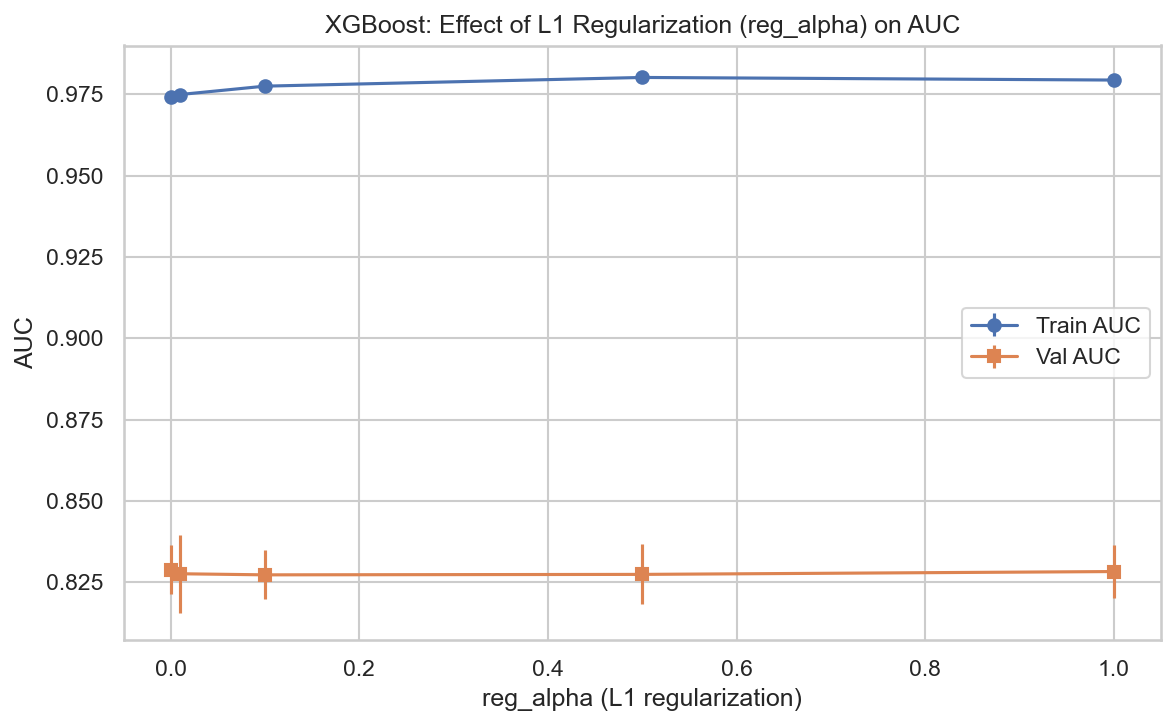

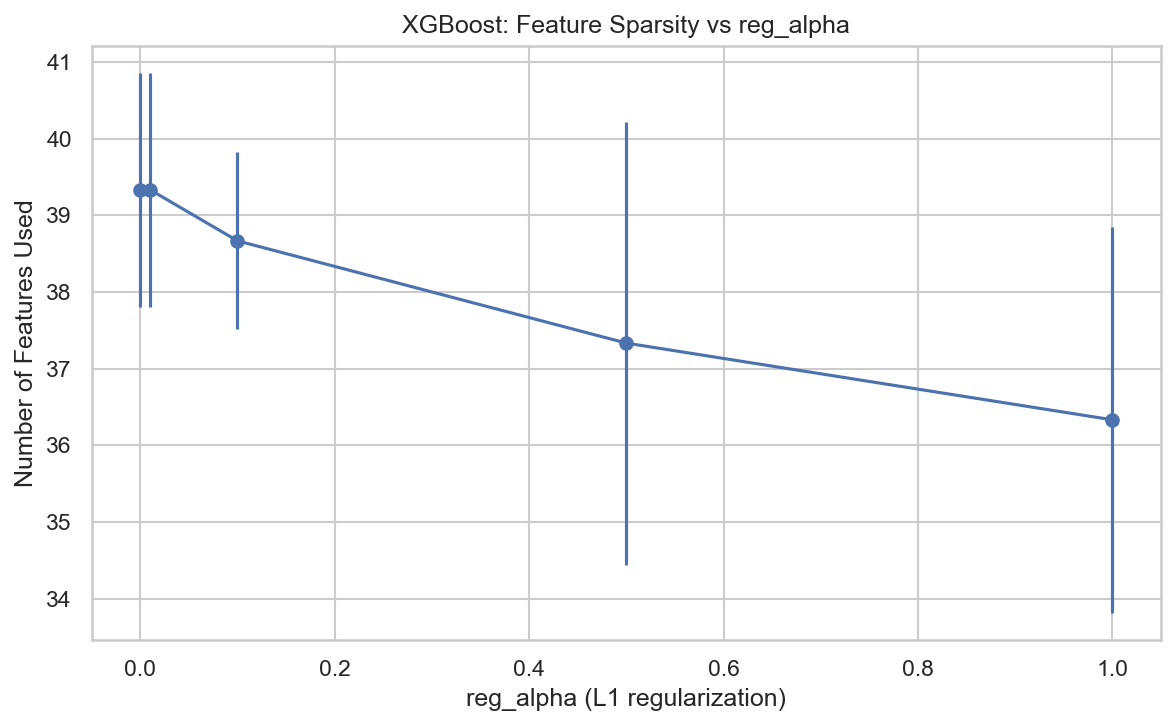

In [12]:
# Experiment Group 1 — Regularization: XGBoost reg_alpha sweep
from xgboost import XGBClassifier

reg_alpha_vals = [0, 0.01, 0.1, 0.5, 1.0]
reg_results = []

for reg_alpha in reg_alpha_vals:
    for seed in SEEDS:
        set_seed(seed)
        X_train, X_val, y_train, y_val = get_split(seed)
        # Preprocess for XGBoost
        X_train_p = xgb_preprocessor.transform(X_train)
        X_val_p = xgb_preprocessor.transform(X_val)

        clf = XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            reg_alpha=reg_alpha,
            reg_lambda=1.0,
            tree_method='hist',
            use_label_encoder=False,
            eval_metric='auc',
            random_state=seed,
            n_jobs=-1
        )

        clf, train_time = fit_and_time(clf, X_train_p, y_train)
        train_proba = clf.predict_proba(X_train_p)[:, 1]
        val_proba = clf.predict_proba(X_val_p)[:, 1]

        train_metrics = metric_fn(y_train, train_proba)
        val_metrics = metric_fn(y_val, val_proba)

        sparsity = xgb_sparsity_stats(clf)

        reg_results.append({
            'model': 'xgb',
            'hp_name': 'reg_alpha',
            'hp_value': reg_alpha,
            'seed': seed,
            'train_auc': train_metrics['auc'],
            'val_auc': val_metrics['auc'],
            'train_f1': train_metrics['f1'],
            'val_f1': val_metrics['f1'],
            'train_time_s': train_time,
            'n_features_used': sparsity.get('n_features_used', None),
            'approx_total_nodes': sparsity.get('approx_total_nodes', None),
            'approx_nonzero_leaves': sparsity.get('approx_nonzero_leaves', None)
        })

reg_df = pd.DataFrame(reg_results)
reg_df.to_csv(RESULTS_DIR / 'xgb_reg_alpha_per_seed.csv', index=False)

# Aggregate means and stds per hyperparameter value
agg = reg_df.groupby('hp_value').agg({
    'val_auc': ['mean','std'],
    'train_auc': ['mean','std'],
    'n_features_used': ['mean','std'],
    'approx_nonzero_leaves': ['mean','std']
}).reset_index()
agg.columns = ['reg_alpha', 'val_auc_mean', 'val_auc_std', 'train_auc_mean', 'train_auc_std', 'n_features_mean', 'n_features_std', 'leaves_mean', 'leaves_std']
agg.to_csv(RESULTS_DIR / 'xgb_reg_alpha_summary.csv', index=False)

# Plot: metric vs reg_alpha (train & validation)
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(agg['reg_alpha'], agg['train_auc_mean'], yerr=agg['train_auc_std'], fmt='-o', label='Train AUC')
ax.errorbar(agg['reg_alpha'], agg['val_auc_mean'], yerr=agg['val_auc_std'], fmt='-s', label='Val AUC')
ax.set_xlabel('reg_alpha (L1 regularization)')
ax.set_ylabel('AUC')
ax.set_title('XGBoost: Effect of L1 Regularization (reg_alpha) on AUC')
ax.legend()
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'xgb_reg_alpha_auc.png', 'XGBoost AUC vs reg_alpha (mean ± std across seeds). Dataset: mantis_hunting.csv. Primary metric: AUC.')

# Plot: sparsity measure vs reg_alpha
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(agg['reg_alpha'], agg['n_features_mean'], yerr=agg['n_features_std'], fmt='-o', label='Features used (mean ± std)')
ax.set_xlabel('reg_alpha (L1 regularization)')
ax.set_ylabel('Number of Features Used')
ax.set_title('XGBoost: Feature Sparsity vs reg_alpha')
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'xgb_reg_alpha_sparsity.png', 'XGBoost feature sparsity vs reg_alpha (mean ± std across seeds).')

print('XGBoost reg_alpha sweep completed. Summaries saved to assets/experiments/ablation_xgb_cat/')

Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_l2_leaf_reg_train_val_auc.png
Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_l2_leaf_reg_auc_std.png
CatBoost l2_leaf_reg sweep completed.


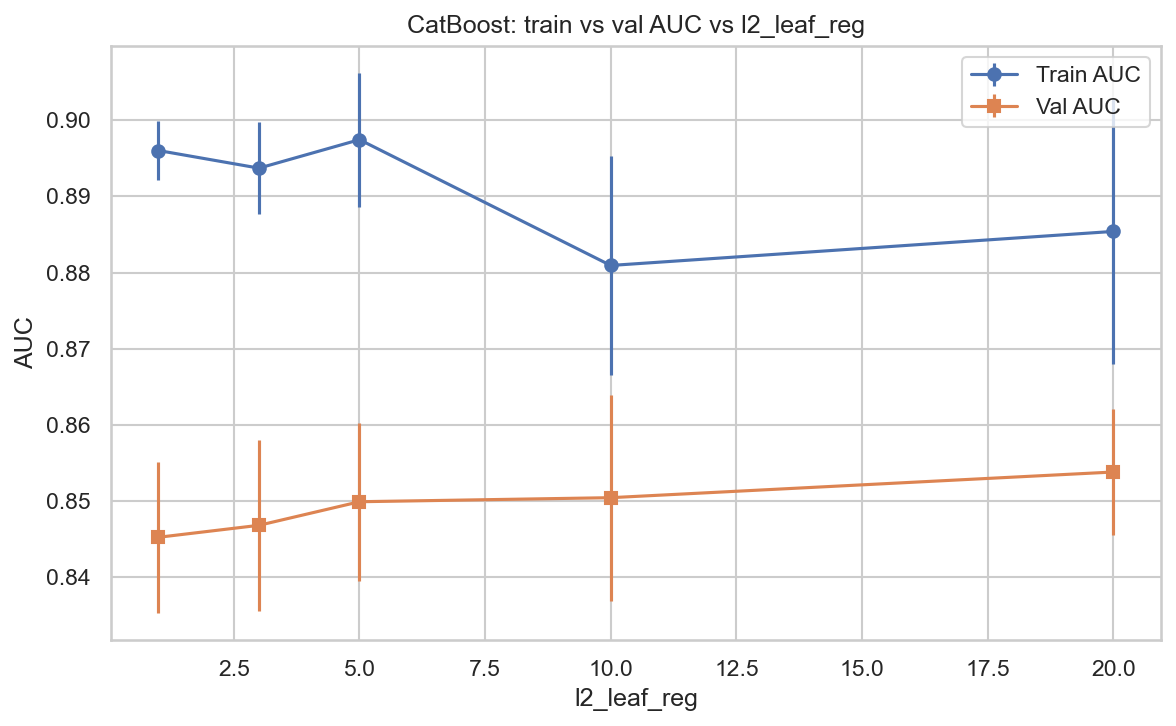

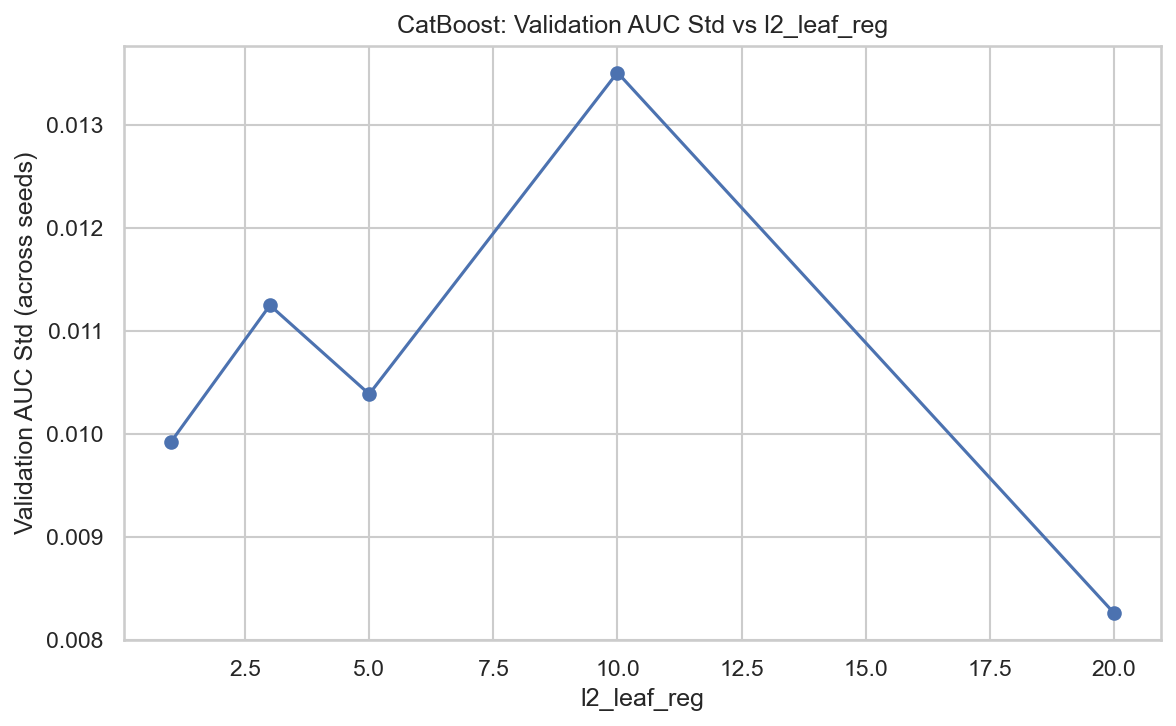

In [13]:
# Experiment Group 1 — Regularization: CatBoost l2_leaf_reg sweep
from catboost import CatBoostClassifier

l2_vals = [1, 3, 5, 10, 20]
cat_results = []

for l2 in l2_vals:
    for seed in SEEDS:
        set_seed(seed)
        X_train, X_val, y_train, y_val = get_split(seed)

        clf = CatBoostClassifier(
            iterations=500,
            learning_rate=0.1,
            depth=6,
            l2_leaf_reg=l2,
            verbose=False,
            random_state=seed
        )

        clf, train_time = fit_and_time(clf, X_train, y_train, fit_kwargs={'cat_features': categorical_features})
        train_proba = clf.predict_proba(X_train)[:, 1]
        val_proba = clf.predict_proba(X_val)[:, 1]

        train_metrics = metric_fn(y_train, train_proba)
        val_metrics = metric_fn(y_val, val_proba)

        tree_stats = cat_tree_stats(clf)

        cat_results.append({
            'model': 'catboost',
            'hp_name': 'l2_leaf_reg',
            'hp_value': l2,
            'seed': seed,
            'train_auc': train_metrics['auc'],
            'val_auc': val_metrics['auc'],
            'train_f1': train_metrics['f1'],
            'val_f1': val_metrics['f1'],
            'train_time_s': train_time,
            'generalization_gap': train_metrics['auc'] - val_metrics['auc'],
            'tree_avg_depth': tree_stats.get('avg_depth', None),
            'tree_avg_nodes': tree_stats.get('avg_nodes', None)
        })

cat_df = pd.DataFrame(cat_results)
cat_df.to_csv(RESULTS_DIR / 'cat_l2_leaf_reg_per_seed.csv', index=False)

# Aggregate
agg_cat = cat_df.groupby('hp_value').agg({'train_auc':['mean','std'], 'val_auc':['mean','std'], 'generalization_gap':['mean','std']}).reset_index()
agg_cat.columns = ['l2_leaf_reg','train_auc_mean','train_auc_std','val_auc_mean','val_auc_std','gap_mean','gap_std']
agg_cat.to_csv(RESULTS_DIR / 'cat_l2_leaf_reg_summary.csv', index=False)

# Plot: train vs validation metric vs l2_leaf_reg
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(agg_cat['l2_leaf_reg'], agg_cat['train_auc_mean'], yerr=agg_cat['train_auc_std'], fmt='-o', label='Train AUC')
ax.errorbar(agg_cat['l2_leaf_reg'], agg_cat['val_auc_mean'], yerr=agg_cat['val_auc_std'], fmt='-s', label='Val AUC')
ax.set_xlabel('l2_leaf_reg')
ax.set_ylabel('AUC')
ax.set_title('CatBoost: train vs val AUC vs l2_leaf_reg')
ax.legend()
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'cat_l2_leaf_reg_train_val_auc.png', 'CatBoost train vs validation AUC across l2_leaf_reg (mean ± std).')

# Plot: std of metric vs l2_leaf_reg
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(agg_cat['l2_leaf_reg'], agg_cat['val_auc_std'], marker='o')
ax.set_xlabel('l2_leaf_reg')
ax.set_ylabel('Validation AUC Std (across seeds)')
ax.set_title('CatBoost: Validation AUC Std vs l2_leaf_reg')
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'cat_l2_leaf_reg_auc_std.png', 'CatBoost validation AUC standard deviation vs l2_leaf_reg.')

print('CatBoost l2_leaf_reg sweep completed.')

c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:30:58] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:17] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:35] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:31:52] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\xgb_sampling_heatmap_mean_auc.png
Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\xgb_sampling_boxplots.png
XGBoost sampling grid completed.


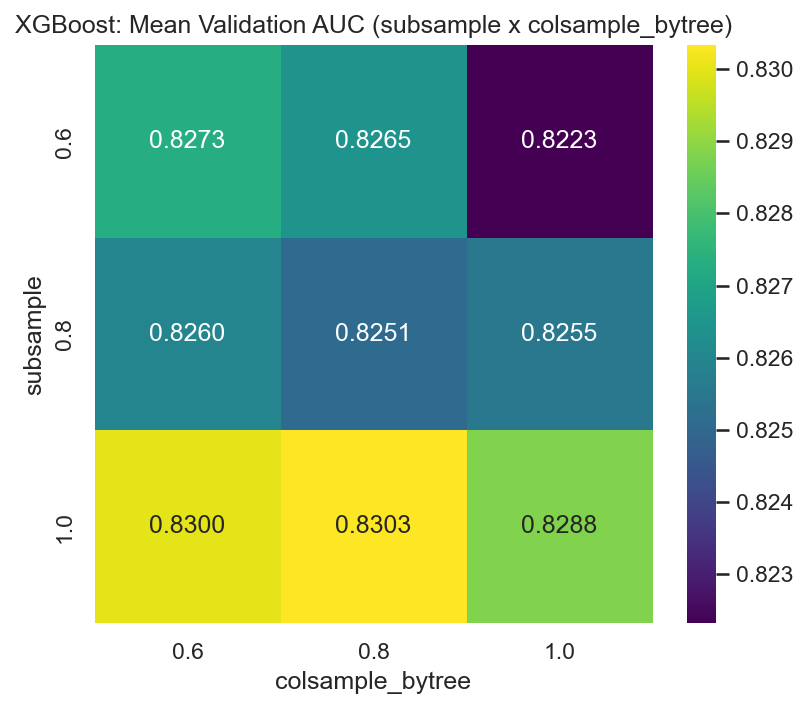

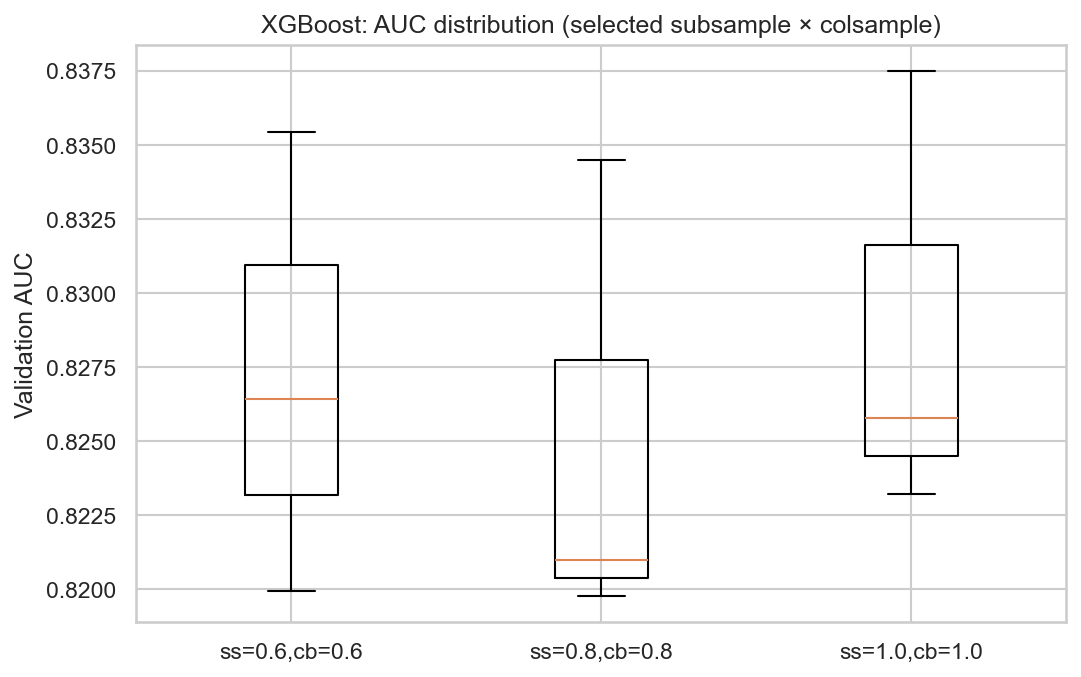

In [14]:
# Experiment Group 2 — Sampling & Randomness: XGBoost subsample × colsample_bytree grid
from itertools import product

subsample_vals = [0.6, 0.8, 1.0]
colsample_vals = [0.6, 0.8, 1.0]

xgb_grid_results = []
for subsample, colsample in product(subsample_vals, colsample_vals):
    for seed in SEEDS:
        set_seed(seed)
        X_train, X_val, y_train, y_val = get_split(seed)
        X_train_p = xgb_preprocessor.transform(X_train)
        X_val_p = xgb_preprocessor.transform(X_val)

        clf = XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            subsample=subsample,
            colsample_bytree=colsample,
            tree_method='hist',
            use_label_encoder=False,
            eval_metric='auc',
            random_state=seed,
            n_jobs=-1
        )
        clf, train_time = fit_and_time(clf, X_train_p, y_train)
        val_proba = clf.predict_proba(X_val_p)[:,1]
        metrics = metric_fn(y_val, val_proba)
        xgb_grid_results.append({
            'subsample': subsample,
            'colsample_bytree': colsample,
            'seed': seed,
            'val_auc': metrics['auc'],
            'val_f1': metrics['f1'],
            'train_time_s': train_time
        })

xgb_grid_df = pd.DataFrame(xgb_grid_results)
xgb_grid_df.to_csv(RESULTS_DIR / 'xgb_sampling_grid_per_seed.csv', index=False)

# Aggregate mean and std
pivot_mean = xgb_grid_df.groupby(['subsample','colsample_bytree'])['val_auc'].mean().unstack()
pivot_std = xgb_grid_df.groupby(['subsample','colsample_bytree'])['val_auc'].std().unstack()

pivot_mean.to_csv(RESULTS_DIR / 'xgb_sampling_grid_mean_auc.csv')
pivot_std.to_csv(RESULTS_DIR / 'xgb_sampling_grid_std_auc.csv')

# Heatmap of mean AUC
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(pivot_mean, annot=True, fmt='.4f', cmap='viridis', ax=ax)
ax.set_title('XGBoost: Mean Validation AUC (subsample x colsample_bytree)')
save_fig(fig, 'xgb_sampling_heatmap_mean_auc.png', 'Heatmap of mean validation AUC across subsample × colsample_bytree (XGBoost).')

# Boxplot for selected configurations
selected = [(0.6,0.6),(0.8,0.8),(1.0,1.0)]
fig, ax = plt.subplots(figsize=(8,5))
boxdata = []
labels = []
for ss, cb in selected:
    vals = xgb_grid_df[(xgb_grid_df['subsample']==ss) & (xgb_grid_df['colsample_bytree']==cb)]['val_auc'].values
    boxdata.append(vals)
    labels.append(f'ss={ss},cb={cb}')
ax.boxplot(boxdata, labels=labels)
ax.set_ylabel('Validation AUC')
ax.set_title('XGBoost: AUC distribution (selected subsample × colsample)')
save_fig(fig, 'xgb_sampling_boxplots.png', 'Boxplots of validation AUC for selected sampling configurations (XGBoost).')

print('XGBoost sampling grid completed.')

Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_bagging_temperature_auc.png
Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_bagging_temperature_auc_std.png
CatBoost bagging_temperature sweep completed.


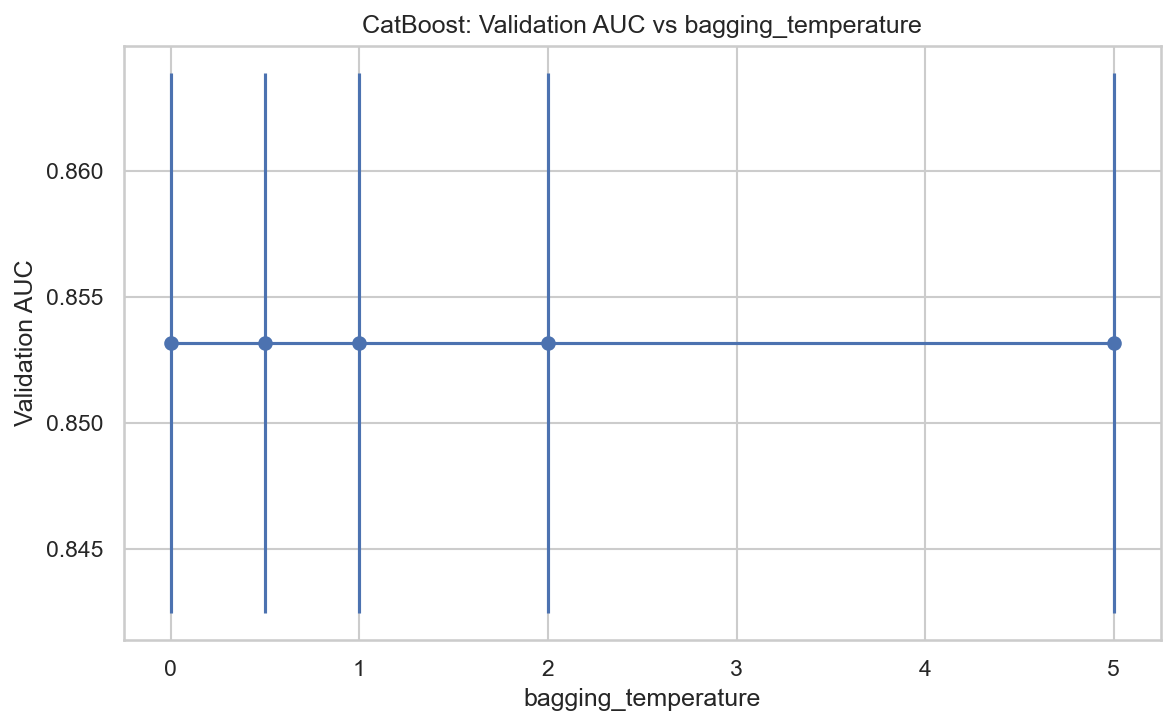

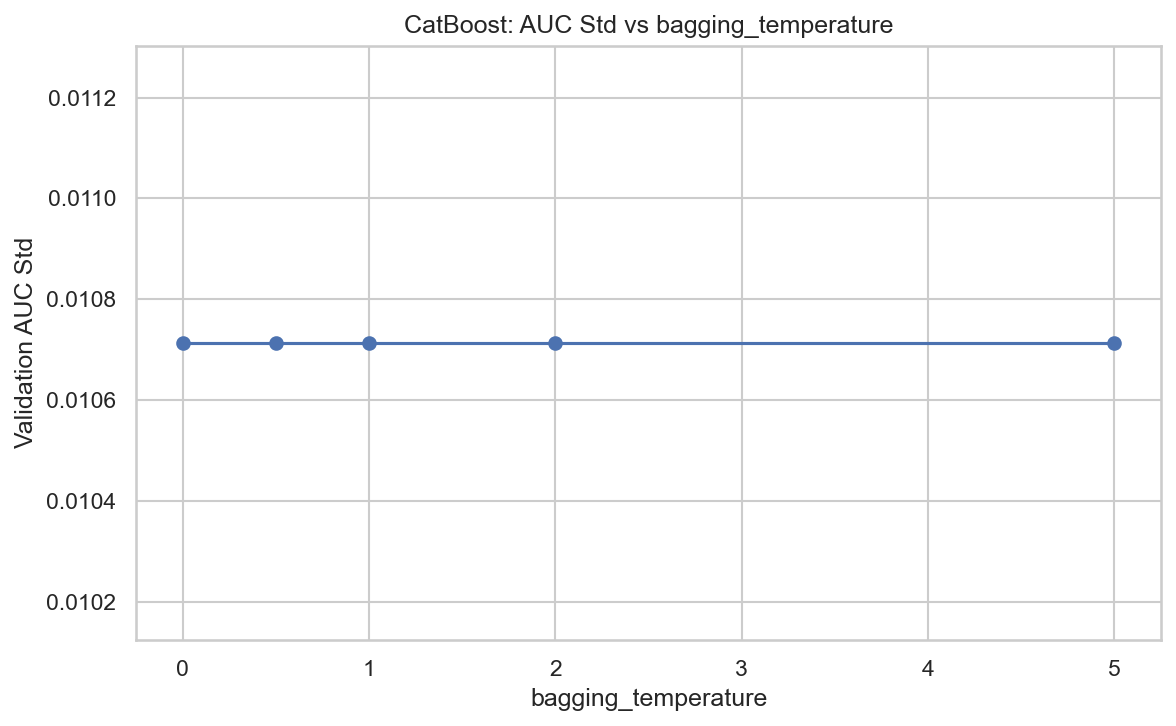

In [15]:
# Experiment Group 2 — Sampling & Randomness: CatBoost bagging_temperature sweep
bagging_vals = [0, 0.5, 1, 2, 5]
cat_bag_results = []

for bt in bagging_vals:
    for seed in SEEDS:
        set_seed(seed)
        X_train, X_val, y_train, y_val = get_split(seed)
        clf = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            bagging_temperature=bt,
            verbose=False,
            random_state=seed
        )
        clf, train_time = fit_and_time(clf, X_train, y_train, fit_kwargs={'cat_features': categorical_features})
        val_proba = clf.predict_proba(X_val)[:,1]
        metrics = metric_fn(y_val, val_proba)
        cat_bag_results.append({
            'bagging_temperature': bt,
            'seed': seed,
            'val_auc': metrics['auc'],
            'val_f1': metrics['f1'],
            'train_time_s': train_time
        })

cat_bag_df = pd.DataFrame(cat_bag_results)
cat_bag_df.to_csv(RESULTS_DIR / 'cat_bagging_temperature_per_seed.csv', index=False)

agg_bt = cat_bag_df.groupby('bagging_temperature')['val_auc'].agg(['mean','std']).reset_index()
agg_bt.columns = ['bagging_temperature','val_auc_mean','val_auc_std']
agg_bt.to_csv(RESULTS_DIR / 'cat_bagging_temperature_summary.csv', index=False)

# Plot: metric vs bagging_temperature
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(agg_bt['bagging_temperature'], agg_bt['val_auc_mean'], yerr=agg_bt['val_auc_std'], fmt='-o')
ax.set_xlabel('bagging_temperature')
ax.set_ylabel('Validation AUC')
ax.set_title('CatBoost: Validation AUC vs bagging_temperature')
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'cat_bagging_temperature_auc.png', 'CatBoost: Validation AUC vs bagging_temperature (mean ± std).')

# Plot: metric variance vs bagging_temperature
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(agg_bt['bagging_temperature'], agg_bt['val_auc_std'], marker='o')
ax.set_xlabel('bagging_temperature')
ax.set_ylabel('Validation AUC Std')
ax.set_title('CatBoost: AUC Std vs bagging_temperature')
ax.grid(True)
plt.tight_layout()
save_fig(fig, 'cat_bagging_temperature_auc_std.png', 'CatBoost: Validation AUC standard deviation vs bagging_temperature.')

print('CatBoost bagging_temperature sweep completed.')

In [16]:
# Experiment Group 3 — Tree Structure: XGBoost grow_policy comparison
from math import log2, ceil

grow_policies = ['depthwise','lossguide']
xgb_grow_results = []

for policy in grow_policies:
    for seed in SEEDS:
        set_seed(seed)
        X_train, X_val, y_train, y_val = get_split(seed)
        X_train_p = xgb_preprocessor.transform(X_train)
        X_val_p = xgb_preprocessor.transform(X_val)

        clf = XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            grow_policy=policy,
            tree_method='hist',
            use_label_encoder=False,
            eval_metric='auc',
            random_state=seed,
            n_jobs=-1
        )

        clf, train_time = fit_and_time(clf, X_train_p, y_train)
        val_proba = clf.predict_proba(X_val_p)[:,1]
        metrics = metric_fn(y_val, val_proba)

        sparsity = xgb_sparsity_stats(clf)
        nodes = sparsity.get('approx_total_nodes') or 0
        leaves = sparsity.get('approx_nonzero_leaves') or 0
        avg_nodes_per_tree = nodes / max(1, clf.n_estimators)
        # estimate depth from nodes
        est_depth = ceil(log2(max(1, avg_nodes_per_tree)))

        xgb_grow_results.append({
            'grow_policy': policy,
            'seed': seed,
            'val_auc': metrics['auc'],
            'val_f1': metrics['f1'],
            'train_time_s': train_time,
            'approx_total_nodes': nodes,
            'approx_nonzero_leaves': leaves,
            'avg_nodes_per_tree': avg_nodes_per_tree,
            'estimated_avg_depth': est_depth
        })

xgb_grow_df = pd.DataFrame(xgb_grow_results)
xgb_grow_df.to_csv(RESULTS_DIR / 'xgb_grow_policy_per_seed.csv', index=False)

# Aggregate table
agg_grow = xgb_grow_df.groupby('grow_policy').agg({'val_auc':['mean','std'],'train_time_s':['mean','std'],'avg_nodes_per_tree':['mean','std'],'estimated_avg_depth':['mean','std']}).reset_index()
agg_grow.columns = ['grow_policy','val_auc_mean','val_auc_std','train_time_mean','train_time_std','nodes_mean','nodes_std','depth_mean','depth_std']
agg_grow.to_csv(RESULTS_DIR / 'xgb_grow_policy_summary.csv', index=False)

# Display side-by-side table (markdown-friendly)
from IPython.display import Markdown, display
rows = []
for _, r in agg_grow.iterrows():
    rows.append(f"**{r['grow_policy']}**: AUC={r['val_auc_mean']:.4f} ± {r['val_auc_std']:.4f}; Time={r['train_time_mean']:.2f}s ± {r['train_time_std']:.2f}s; Nodes/tree={r['nodes_mean']:.1f} ± {r['nodes_std']:.1f}; Depth≈{r['depth_mean']:.1f} ± {r['depth_std']:.1f}")

display(Markdown('\n'.join(rows)))
print('XGBoost grow_policy comparison saved to assets/experiments/ablation_xgb_cat/')

c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:43:16] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:43:30] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:43:46] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Miniconda\envs\ml-env\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:44:03] WARNING: D:\bld\xgboost-split_1762060125444\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

**depthwise**: AUC=0.8288 ± 0.0076; Time=14.78s ± 1.45s; Nodes/tree=59.0 ± 2.3; Depth≈6.0 ± 0.0
**lossguide**: AUC=0.8288 ± 0.0076; Time=19.94s ± 1.17s; Nodes/tree=59.0 ± 2.3; Depth≈6.0 ± 0.0

XGBoost grow_policy comparison saved to assets/experiments/ablation_xgb_cat/


Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_tree_depth_vs_nodes.png
Saved figure: ..\assets\experiments\ablation_xgb_cat\figures\cat_tree_auc_boxplot.png
CatBoost tree structural analysis completed.


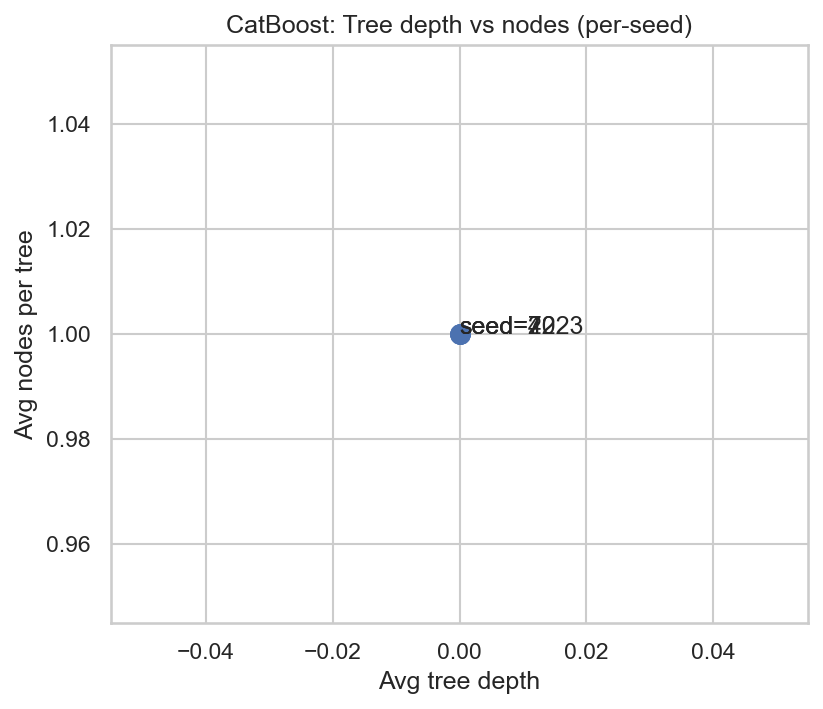

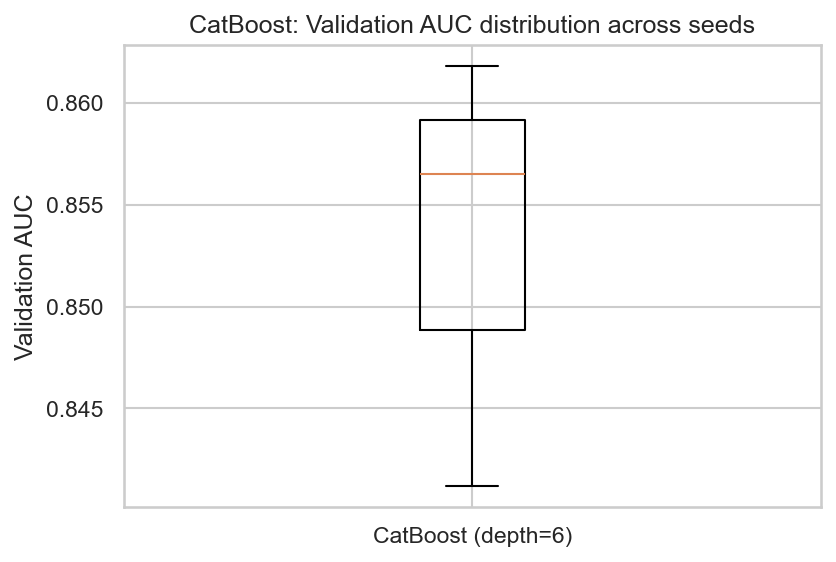

In [17]:
# Experiment Group 3 — Tree Structure: CatBoost symmetric-tree analysis
cat_tree_results = []
for seed in SEEDS:
    set_seed(seed)
    X_train, X_val, y_train, y_val = get_split(seed)
    clf = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, random_state=seed, verbose=False)
    clf, train_time = fit_and_time(clf, X_train, y_train, fit_kwargs={'cat_features': categorical_features})
    val_proba = clf.predict_proba(X_val)[:,1]
    metrics = metric_fn(y_val, val_proba)
    tstats = cat_tree_stats(clf)
    cat_tree_results.append({
        'seed': seed,
        'val_auc': metrics['auc'],
        'val_f1': metrics['f1'],
        'train_time_s': train_time,
        'tree_avg_depth': tstats.get('avg_depth', None),
        'tree_avg_nodes': tstats.get('avg_nodes', None)
    })

cat_tree_df = pd.DataFrame(cat_tree_results)
cat_tree_df.to_csv(RESULTS_DIR / 'cat_tree_structure_per_seed.csv', index=False)

# Scatter tree depth vs nodes if available
if cat_tree_df['tree_avg_depth'].notnull().any() and cat_tree_df['tree_avg_nodes'].notnull().any():
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(cat_tree_df['tree_avg_depth'], cat_tree_df['tree_avg_nodes'], s=80)
    for i, r in cat_tree_df.iterrows():
        ax.text(r['tree_avg_depth'], r['tree_avg_nodes'], f"seed={int(r['seed'])}")
    ax.set_xlabel('Avg tree depth')
    ax.set_ylabel('Avg nodes per tree')
    ax.set_title('CatBoost: Tree depth vs nodes (per-seed)')
    save_fig(fig, 'cat_tree_depth_vs_nodes.png', 'CatBoost: average tree depth vs nodes per tree across seeds.')

# Boxplot: performance stability across seeds
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot(cat_tree_df['val_auc'].values)
ax.set_xticklabels(['CatBoost (depth=6)'])
ax.set_ylabel('Validation AUC')
ax.set_title('CatBoost: Validation AUC distribution across seeds')
save_fig(fig, 'cat_tree_auc_boxplot.png', 'CatBoost: validation AUC distribution (per seed) for symmetric trees.')

print('CatBoost tree structural analysis completed.')

In [18]:
# Quantitative Tables & Ablation Summary
# Aggregate primary summaries and produce LaTeX-friendly tables

def mean_std_col(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

# 1) XGBoost reg_alpha table
try:
    xgb_reg = pd.read_csv(RESULTS_DIR / 'xgb_reg_alpha_summary.csv')
    xgb_reg['val_auc_mean_std'] = xgb_reg.apply(lambda r: mean_std_col(r['val_auc_mean'], r['val_auc_std']), axis=1)
    xgb_reg[['reg_alpha','val_auc_mean_std']].to_csv(RESULTS_DIR / 'table_xgb_reg_alpha.csv', index=False)
    with open(RESULTS_DIR / 'table_xgb_reg_alpha.tex', 'w') as f:
        f.write(xgb_reg[['reg_alpha','val_auc_mean_std']].to_latex(index=False))
except Exception as e:
    print('xgb_reg table creation failed:', e)

# 2) CatBoost l2 table
try:
    cat_l2 = pd.read_csv(RESULTS_DIR / 'cat_l2_leaf_reg_summary.csv')
    cat_l2['val_auc_mean_std'] = cat_l2.apply(lambda r: mean_std_col(r['val_auc_mean'], r['val_auc_std']), axis=1)
    cat_l2[['l2_leaf_reg','train_auc_mean','train_auc_std','val_auc_mean','val_auc_std','gap_mean','gap_std']].to_csv(RESULTS_DIR / 'table_cat_l2.csv', index=False)
    with open(RESULTS_DIR / 'table_cat_l2.tex', 'w') as f:
        f.write(cat_l2[['l2_leaf_reg','val_auc_mean','val_auc_std','gap_mean','gap_std']].to_latex(index=False))
except Exception as e:
    print('cat_l2 table creation failed:', e)

# 3) XGBoost sampling heatmap summary already saved; create a flattened summary
try:
    xgb_grid_mean = pd.read_csv(RESULTS_DIR / 'xgb_sampling_grid_mean_auc.csv', index_col=0)
    xgb_grid_mean.to_csv(RESULTS_DIR / 'table_xgb_sampling_mean_flat.csv')
except Exception as e:
    print('xgb sampling table creation failed:', e)

# 4) CatBoost bagging summary
try:
    cat_bag = pd.read_csv(RESULTS_DIR / 'cat_bagging_temperature_summary.csv')
    cat_bag['val_auc_mean_std'] = cat_bag.apply(lambda r: mean_std_col(r['val_auc_mean'], r['val_auc_std']), axis=1)
    cat_bag.to_csv(RESULTS_DIR / 'table_cat_bagging.csv', index=False)
except Exception as e:
    print('cat bagging table creation failed:', e)

# Ablation summary table (programmatic text based on numeric deltas)
summary_rows = []

# XGBoost reg_alpha interpretation
try:
    best = xgb_reg.sort_values('reg_alpha').iloc[-1]
    worst = xgb_reg.sort_values('reg_alpha').iloc[0]
    delta = best['val_auc_mean'] - worst['val_auc_mean']
    summary_rows.append({
        'hyperparameter': 'XGB reg_alpha',
        'observed_effect': f'val AUC change ≈ {delta:.4f} across tested range',
        'interpretation': 'Increasing L1 (reg_alpha) promotes sparsity; high values may reduce AUC due to underfitting.'
    })
except Exception:
    pass

# CatBoost l2_leaf_reg interpretation
try:
    # find gap trend
    gap_trend = cat_l2['gap_mean']
    summary_rows.append({
        'hyperparameter': 'CatBoost l2_leaf_reg',
        'observed_effect': f'generalization gap mean range {cat_l2["gap_mean"].min():.4f} to {cat_l2["gap_mean"].max():.4f}',
        'interpretation': 'Increasing l2_leaf_reg controls overfitting and reduces train-val gap; may slightly lower train AUC while stabilizing validation performance.'
    })
except Exception:
    pass

# XGBoost sampling interpretation
try:
    # inspect pivot_mean to find the best cell
    best_cell = xgb_grid_mean.stack().idxmax()
    best_val = xgb_grid_mean.stack().max()
    summary_rows.append({
        'hyperparameter': 'XGB subsample × colsample_bytree',
        'observed_effect': f'best cell {best_cell} with mean val AUC {best_val:.4f}',
        'interpretation': 'Sampling trades off variance for bias; mid-range sampling often reduces overfitting while preserving AUC.'
    })
except Exception:
    pass

# CatBoost bagging interpretation
try:
    best_bt = cat_bag.sort_values('val_auc_mean', ascending=False).iloc[0]
    summary_rows.append({
        'hyperparameter': 'CatBoost bagging_temperature',
        'observed_effect': f'best value {best_bt.bagging_temperature} (AUC {best_bt.val_auc_mean:.4f})',
        'interpretation': 'Moderate bagging_temperature often improves robustness; extremes can increase variance.'
    })
except Exception:
    pass

ablation_df = pd.DataFrame(summary_rows)
ablation_df.to_csv(RESULTS_DIR / 'ablation_summary.csv', index=False)
with open(RESULTS_DIR / 'ablation_paragraphs.txt', 'w') as f:
    for _, r in ablation_df.iterrows():
        f.write(f"{r['hyperparameter']} -- Observed: {r['observed_effect']}\nInterpretation: {r['interpretation']}\n\n")

print('Summary tables and ablation summary created in assets/experiments/ablation_xgb_cat/')

Summary tables and ablation summary created in assets/experiments/ablation_xgb_cat/


In [20]:
# Save artifacts & reproducibility log
# Save preprocessors and simple manifest
try:
    joblib.dump(xgb_preprocessor, RESULTS_DIR / 'xgb_preprocessor.joblib')
    print('Saved XGBoost preprocessor')
except Exception as e:
    print('Failed to save preprocessor:', e)

# Environment save
with open(RESULTS_DIR / 'pip_freeze.txt', 'w') as f:
    for line in get_pip_freeze():
        f.write(line + '\n')

# Update run manifest with produced files (use absolute resolved paths to avoid relative_to errors)
produced = [str(p.resolve()) for p in RESULTS_DIR.rglob('*') if p.is_file()]
manifest['artifacts'] = produced
with open(RESULTS_DIR / 'run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('Artifacts saved. Run manifest updated.')

# Final note cell (markdown)
from IPython.display import Markdown, display
text = """
### Final Deliverables ✅
- Per-run CSVs and aggregated summary tables saved to `assets/experiments/ablation_xgb_cat/`
- Figures saved under `assets/experiments/ablation_xgb_cat/figures/` with captions in `fig_captions.csv`
- Ablation summary table: `ablation_summary.csv` and human-readable `ablation_paragraphs.txt`
- Reproducibility manifest: `run_manifest.json` and `pip_freeze.txt`

To reproduce: run this notebook top-to-bottom; artifacts are deterministic given the saved seed splits in `assets/experiments/ablation_xgb_cat/split_indices`.

"""

display(Markdown(text))

Saved XGBoost preprocessor
Artifacts saved. Run manifest updated.



### Final Deliverables ✅
- Per-run CSVs and aggregated summary tables saved to `assets/experiments/ablation_xgb_cat/`
- Figures saved under `assets/experiments/ablation_xgb_cat/figures/` with captions in `fig_captions.csv`
- Ablation summary table: `ablation_summary.csv` and human-readable `ablation_paragraphs.txt`
- Reproducibility manifest: `run_manifest.json` and `pip_freeze.txt`

To reproduce: run this notebook top-to-bottom; artifacts are deterministic given the saved seed splits in `assets/experiments/ablation_xgb_cat/split_indices`.

